In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
%cd /content/drive/MyDrive/24-1/AI전공/PJ_FireForest/2.코드/my/

/content/drive/MyDrive/24-1/AI전공/PJ_FireForest/2.코드/my


In [28]:
from PIL import Image
import os
import glob
import pandas as pd

In [29]:
try:
    os.makedirs('data/colorEnhanced/train/NoFire')
    os.makedirs('data/colorEnhanced/val/NoFire')
    os.makedirs('data/colorEnhanced/train/Fire')
    os.makedirs('data/colorEnhanced/val/Fire')
except:
    print("folder already exist")

perc = .05
print("percent to change Fire", perc)

def shiftIm(fldrIn, fn, fldrOut, perc=-.04, type='png'):
    path = fldrIn + fn
    im = Image.open(path).convert('RGB')

    r, g, b = im.split()

    r = r.point(lambda i: i * (1+perc))
    g = g.point(lambda i: i * (1-perc))

    result = Image.merge('RGB', (r, g, b))

    result.save(f'{fldrOut}/{fn}')
    im.close()


import glob
FireList = []
NoFireList = []

fldrIn = "data/synthetic/train/Fire/"
fldrOut = "data/colorEnhanced/train/Fire/"
for fire, fn in enumerate(glob.glob(fldrIn+"*.png")):
    fn_trunc = fn.split('/')[-1]
    FireList.append(fn_trunc)
    shiftIm(fldrIn, fn_trunc, fldrOut, perc, 'png')
print("completed train set")
fldrIn = "data/synthetic/val/Fire/"
fldrOut = "data/colorEnhanced/val/Fire/"
for fire, fn in enumerate(glob.glob(fldrIn+"*.png")):
    fn_trunc = fn.split('/')[-1]
    FireList.append(fn_trunc)
    shiftIm(fldrIn, fn_trunc, fldrOut, perc, 'png')
print("completed val set")

perc = -1 * perc
print("percent to change NoFire", perc)

fldrIn = "data/synthetic/train/NoFire/"
fldrOut = "data/colorEnhanced/train/NoFire"
for fire, fn in enumerate(glob.glob(fldrIn+"*.png")):
    fn_trunc = fn.split('/')[-1]
    FireList.append(fn_trunc)
    shiftIm(fldrIn, fn_trunc, fldrOut, perc, 'png')
print("completed train set")
fldrIn = "data/synthetic/val/NoFire/"
fldrOut = "data/colorEnhanced/val/NoFire/"
for fire, fn in enumerate(glob.glob(fldrIn+"*.png")):
    fn_trunc = fn.split('/')[-1]
    FireList.append(fn_trunc)
    shiftIm(fldrIn, fn_trunc, fldrOut, perc, 'png')
print("completed val set")
print(f"File created: { len(glob.glob('data/synthetic/*/*/*.png')) }")
print("done")

folder already exist
percent to change Fire 0.05
completed train set
completed val set
percent to change NoFire -0.05
completed train set
completed val set
File created: 250
done


In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from shapely.geometry import Point
from shapely.geometry import Polygon as GPoly
import pandas as pd
import numpy as np

In [31]:
usgs = pd.read_csv('data/USGS_NAIP_Sampled_Mapping.csv')
usgs['Longitude'] = usgs['Centroid'].apply(lambda x: float(x.split('(')[-1].replace(')','').replace(' ','').split(',')[0]))
usgs['Lattitude'] = usgs['Centroid'].apply(lambda x: float(x.split('(')[-1].replace(')','').replace(' ','').split(',')[1]))

In [32]:
import glob
SyntheticTrainFirefn = []
SyntheticTrainNoFirefn = []
SyntheticValFirefn = []
SyntheticValNoFirefn = []

path = 'data/colorEnhanced/train/Fire/*.png'
for fn in glob.glob(path):
    SyntheticTrainFirefn.append(fn.split('/')[-1])

path = 'data/colorEnhanced/val/Fire/*.png'
for fn in glob.glob(path):
    SyntheticValFirefn.append(fn.split('/')[-1])

path = 'data/colorEnhanced/train/NoFire/*.png'
for fn in glob.glob(path):
    SyntheticTrainNoFirefn.append(fn.split('/')[-1])

path = 'data/colorEnhanced/val/NoFire/*.png'
for fn in glob.glob(path):
    SyntheticValNoFirefn.append(fn.split('/')[-1])

In [33]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from shapely.geometry import Polygon as GPoly
from shapely.geometry import Point
import random
import numpy as np

125


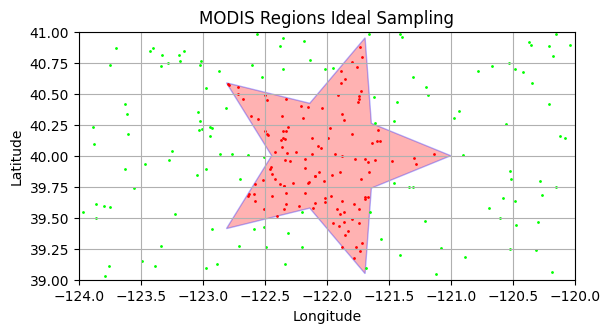

In [34]:
use = len(SyntheticTrainFirefn) + len(SyntheticValFirefn)  # subsample the number of images we have in  folders
print(use)

fig, ax = plt.subplots()

N_rnd = 2000

xrnd = 4*np.random.sample(N_rnd) - 124
yrnd = 2*np.random.sample(N_rnd) + 39
prnd = np.array(list(zip(xrnd, yrnd)))

# Create star shape for synthetic MODIS
import numpy as np
pi = np.pi
x = []
y = []
for k in range(0,5):
    r = 4/9
    x.append( r*np.cos(2*pi*k/5 - 2*pi/10) - 122 )
    y.append( r*np.sin(2*pi*k/5 - 2*pi/10) + 40 )
    r = 1
    x.append(  r*np.cos(2*pi*k/5) - 122)
    y.append(  r*np.sin(2*pi*k/5) + 40)

polyStar =  np.array(list(zip(x,y)))
polyStarP = Polygon(polyStar, closed=True,  fc=(1,0,0,0.3),  ec=(0,0,1,0.3))
polyStarG = GPoly(polyStar)
ax.add_patch(polyStarP)

# Color polyStar points red
test = []
for point in prnd:
    #test.append(point_out_polygon(point, polyStar))
    test.append(not polyStarG.contains(Point(point)))
test = np.array(test)
VertNoFire = np.array(list(zip(xrnd[test==True], yrnd[test==True])))

np.save('data/SyntheticVerticesTrainNoFire.npy', VertNoFire[:100])
np.save('data/SyntheticVerticesValNoFire.npy', VertNoFire[100:125])

# Color polyStar points red
test = []
for point in prnd:
    #test.append(point_in_polygon(point, polyStar))
    test.append(polyStarG.contains(Point(point)))
test = np.array(test)
VertFire = np.array(list(zip(xrnd[test==True], yrnd[test==True])))

np.save('data/SyntheticVerticesTrainFire.npy', VertFire[:100])
np.save('data/SyntheticVerticesValFire.npy', VertFire[100:125])

plt.scatter(VertFire[:use,0], VertFire[:use,1], s= 1, c='r')
plt.scatter(VertNoFire[:use,0], VertNoFire[:use,1], s= 1, c='lime')

# Set the aspect ratio and limits
plt.gca().set_aspect('equal')
plt.xlim(-124, -120)
plt.ylim(39.0, 41.0)
plt.grid()
# Set labels and title
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('MODIS Regions Ideal Sampling')

# Show the plot
plt.show()

In [35]:
import pandas as pd
df1 = pd.DataFrame(VertNoFire[:125])
df1['Class'] = 'NoFire'
df1['Name'] = SyntheticTrainNoFirefn + SyntheticValNoFirefn

df2 = pd.DataFrame(VertFire[:125])
df2['Class'] = 'Fire'
df2['Name'] = SyntheticTrainFirefn + SyntheticValFirefn

ColorEnhanced_df = pd.concat([df1, df2])
ColorEnhanced_df.columns = ['Long', 'Lat', 'Class', 'Name']
ColorEnhanced_df.to_csv('data/ColorEnhanced_Mapping.csv')
ColorEnhanced_df

,Long,Lat,Class,Name
0,-120.261350,39.685229,NoFire,m_3912045_ne_10_h_20160712_mid-day_with_clear_...
1,-121.953258,40.704596,NoFire,m_3912045_ne_10_h_20160712_dense_vegetation_wi...
2,-123.785421,39.029141,NoFire,m_3912057_sw_10_h_20160711_early_morning_with_...
3,-121.409903,40.978929,NoFire,m_3912057_sw_10_h_20160711_early_morning_with_...
4,-121.302623,39.745532,NoFire,m_3912057_sw_10_h_20160711_late_afternoon_with...
...,...,...,...,...
120,-121.717121,40.794877,Fire,m_4012355_se_10_h_20160713_late_afternoon_with...
121,-121.278400,39.935575,Fire,m_4012355_se_10_h_20160713_late_afternoon_with...
122,-122.271325,39.776566,Fire,m_4012355_se_10_h_20160713_mid-day_signs_of_wi...
123,-122.341798,39.573836,Fire,m_4012355_se_10_h_20160713_mid-day_signs_of_wi...


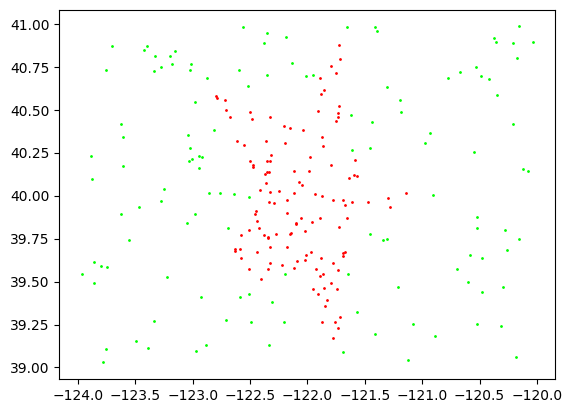

In [36]:
plt.scatter(VertFire[:125,0], VertFire[:125,1], c = 'r', s = 1)
plt.scatter(VertNoFire[:125,0], VertNoFire[:125,1], c = 'lime', s = 1)

In [37]:
print("Done!")

Done!
